# BCI IV-2a Paper Replication — R1 to R5

This notebook is organized as a complete experimental pipeline:

- **R1:** Load `eeg_bundle.pkl`, validate shapes, strict subject/session split, preprocessing.
- **R2:** 10-band OVR-CSP and LASSO sparse feature selection.
- **R3:** Four independent class-specific FBGANs for each target subject.
- **R4:** CRNN-DF classifier with center-loss style discriminative feature learning.
- **R5:** Strict LOSO evaluation on the held-out subject's test session.

## Recommended execution order

1. Put this notebook and `eeg_bundle.pkl` in the same folder.
2. Run the installation cell once if packages are missing.
3. Keep `RUN_GAN = False` and run Subject A1 first.
4. Run baseline LOSO.
5. Change `RUN_GAN = True` and test A1.
6. Only then start full GAN LOSO, because it is computationally expensive.

The notebook includes checkpoint files so completed subject folds are not lost if execution stops.

In [1]:
# Run only if packages are missing:
# %pip install numpy scipy scikit-learn matplotlib torch pandas

In [2]:
import os
import gc
import time
import copy
import pickle
import random
import warnings

import numpy as np
import pandas as pd
import scipy.signal as sig
from scipy.linalg import eigh

import matplotlib.pyplot as plt

from sklearn.linear_model import LassoCV
from sklearn.metrics import accuracy_score, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.utils import spectral_norm
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: mps


## Configuration

In [3]:
# ---------------- DATA / SIGNAL ----------------
FS = 250
N_CLASSES = 4
CLASSES = ["Left Hand", "Right Hand", "Feet", "Tongue"]

BANDS = [
    (1,4), (4,8), (8,12), (12,16), (16,20),
    (20,24), (24,28), (28,32), (32,35), (35,38)
]

N_CSP_PER_CLASS = 4
MIN_LASSO_FEATURES = 20

# ---------------- CRNN-DF ----------------
CRNN_EPOCHS = 150
CRNN_BATCH = 32
CRNN_LR = 1e-4
CRNN_WEIGHT_DECAY = 1e-4
WARMUP = 30
CENTER_LAMBDA = 0.1
CENTER_ALPHA = 0.02
CENTER_EXPAND_EVERY = 15

# ---------------- FBGAN ----------------
RUN_GAN = False          # First validate with False
NOISE_DIM = 1600
N_FAKE = 750             # per class
GAN_EPOCHS = 200
GAN_BATCH = 5
LR_G = 2e-4
LR_D = 1e-4

# ---------------- EXECUTION ----------------
DEMO_SUBJECT = "1"
CHECKPOINT_DIR = "paper_replication_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Configuration ready.")

Configuration ready.


## R1 — Load and validate the EEG bundle

In [4]:
BUNDLE_PATH = "eeg_bundle.pkl"

if not os.path.exists(BUNDLE_PATH):
    raise FileNotFoundError(
        "eeg_bundle.pkl was not found. Put the file in the same folder as this notebook."
    )

with open(BUNDLE_PATH, "rb") as f:
    bundle = pickle.load(f)

X_raw = np.asarray(bundle["X_raw"], dtype=np.float32)
y = np.asarray(bundle["y"], dtype=np.int64)
subjects = np.asarray(bundle["subjects"]).astype(str)
sessions = np.asarray(bundle["sessions"]).astype(str)

session_values = sorted(np.unique(sessions))
if len(session_values) < 2:
    raise ValueError(f"Expected at least 2 sessions, found: {session_values}")

S0 = str(bundle.get("S0", session_values[0]))
S1 = str(bundle.get("S1", session_values[1]))

print("X_raw:", X_raw.shape)
print("y:", y.shape)
print("Subjects:", sorted(np.unique(subjects), key=lambda x: int(x)))
print("Sessions:", np.unique(sessions))
print("S0:", S0, "| S1:", S1)
print("Class counts:", np.bincount(y, minlength=N_CLASSES))

assert X_raw.ndim == 3
assert X_raw.shape[1] == 22
assert len(X_raw) == len(y) == len(subjects) == len(sessions)
assert set(np.unique(y)) == set(range(N_CLASSES))

print("Bundle validation passed.")

X_raw: (5184, 22, 1000)
y: (5184,)
Subjects: ['1', '2', '3', '4', '5', '6', '7', '8', '9']
Sessions: ['0train' '1test']
S0: 0train | S1: 1test
Class counts: [1296 1296 1296 1296]
Bundle validation passed.


In [5]:
def bandpass(X, lo, hi, fs=FS, order=4):
    sos = sig.butter(
        order,
        [lo, hi],
        btype="bandpass",
        fs=fs,
        output="sos"
    )
    return sig.sosfiltfilt(sos, X, axis=-1).astype(np.float32)


def fit_zscore(X_train):
    mu = X_train.mean(axis=(0, 2), keepdims=True)
    sd = X_train.std(axis=(0, 2), keepdims=True) + 1e-6
    return mu.astype(np.float32), sd.astype(np.float32)


def apply_zscore(X, mu, sd):
    return ((X - mu) / sd).astype(np.float32)


def prepare_loso_fold(test_subj):
    test_subj = str(test_subj)

    m_source = subjects != test_subj
    m_cal = (subjects == test_subj) & (sessions == S0)
    m_test = (subjects == test_subj) & (sessions == S1)

    X_source = X_raw[m_source]
    y_source = y[m_source]

    X_cal = X_raw[m_cal]
    y_cal = y[m_cal]

    X_test = X_raw[m_test]
    y_test = y[m_test]

    if len(X_cal) == 0 or len(X_test) == 0:
        raise ValueError(
            f"Subject {test_subj}: empty calibration or test split. "
            f"Check S0={S0}, S1={S1}, available={np.unique(sessions)}"
        )

    # Fit normalization only on source subjects.
    mu, sd = fit_zscore(X_source)

    X_source = apply_zscore(X_source, mu, sd)
    X_cal = apply_zscore(X_cal, mu, sd)
    X_test = apply_zscore(X_test, mu, sd)

    return X_source, y_source, X_cal, y_cal, X_test, y_test


for s in sorted(np.unique(subjects), key=lambda x: int(x)):
    Xs, ys, Xc, yc, Xt, yt = prepare_loso_fold(s)
    print(
        f"A{s}: source={len(Xs)}, cal={len(Xc)}, test={len(Xt)}, "
        f"cal classes={np.bincount(yc, minlength=4).tolist()}, "
        f"test classes={np.bincount(yt, minlength=4).tolist()}"
    )

A1: source=4608, cal=288, test=288, cal classes=[72, 72, 72, 72], test classes=[72, 72, 72, 72]
A2: source=4608, cal=288, test=288, cal classes=[72, 72, 72, 72], test classes=[72, 72, 72, 72]
A3: source=4608, cal=288, test=288, cal classes=[72, 72, 72, 72], test classes=[72, 72, 72, 72]
A4: source=4608, cal=288, test=288, cal classes=[72, 72, 72, 72], test classes=[72, 72, 72, 72]
A5: source=4608, cal=288, test=288, cal classes=[72, 72, 72, 72], test classes=[72, 72, 72, 72]
A6: source=4608, cal=288, test=288, cal classes=[72, 72, 72, 72], test classes=[72, 72, 72, 72]
A7: source=4608, cal=288, test=288, cal classes=[72, 72, 72, 72], test classes=[72, 72, 72, 72]
A8: source=4608, cal=288, test=288, cal classes=[72, 72, 72, 72], test classes=[72, 72, 72, 72]
A9: source=4608, cal=288, test=288, cal classes=[72, 72, 72, 72], test classes=[72, 72, 72, 72]


## R2 — Filter-bank OVR-CSP and LASSO

The CSP stage creates:

`10 bands × 4 one-vs-rest classes × 4 CSP components = 160 candidate features`

LASSO then selects a sparse subset. The selected CSP spatial filters are also used by the FBGAN filter-bank discriminator.

In [6]:
def mean_normalized_cov(X):
    covs = []

    for trial in X:
        C = trial @ trial.T
        C = C / (np.trace(C) + 1e-8)
        covs.append(C)

    return np.mean(covs, axis=0)


def fit_ovr_csp(X_band, y_train, n_comp=N_CSP_PER_CLASS):
    classes = np.arange(N_CLASSES)
    W_list = []

    for cls in classes:
        X1 = X_band[y_train == cls]
        X0 = X_band[y_train != cls]

        R1 = mean_normalized_cov(X1)
        R0 = mean_normalized_cov(X0)

        reg = 1e-6 * np.eye(R1.shape[0])
        vals, vecs = eigh(R1 + reg, R1 + R0 + 2 * reg)

        idx = np.argsort(vals)[::-1][:n_comp]
        W = vecs[:, idx].astype(np.float32)
        W_list.append(W)

    return W_list


def apply_csp_features(X_band, W_list):
    features = []

    for W in W_list:
        Z = np.einsum("ck,nct->nkt", W, X_band)
        var = np.var(Z, axis=2)
        var = var / (var.sum(axis=1, keepdims=True) + 1e-8)
        features.append(np.log(var + 1e-8))

    return np.concatenate(features, axis=1).astype(np.float32)


def fit_filterbank_csp(X_fit, y_fit):
    all_features = []
    all_W = []

    for band_i, (lo, hi) in enumerate(BANDS):
        print(f"  CSP band {band_i+1:02d}/{len(BANDS)}: {lo}-{hi} Hz")

        Xb = bandpass(X_fit, lo, hi)
        W_list = fit_ovr_csp(Xb, y_fit)

        Fb = apply_csp_features(Xb, W_list)

        all_features.append(Fb)
        all_W.append(W_list)

    F_all = np.concatenate(all_features, axis=1)

    return F_all, all_W


def lasso_select(F_train, y_train, min_k=MIN_LASSO_FEATURES):
    model = LassoCV(
        cv=5,
        max_iter=30000,
        random_state=SEED,
        n_jobs=-1
    )

    model.fit(F_train, y_train.astype(float))

    coef = np.abs(model.coef_)
    idx = np.where(coef > 0)[0]

    if len(idx) < min_k:
        idx = np.argsort(coef)[::-1][:min_k]

    return np.sort(idx), coef, model


def selected_spatial_filters(all_W, selected_idx):
    selected = []

    # Per band: 4 classes × 4 components = 16 features.
    for idx in selected_idx:
        band_id = idx // 16
        local = idx % 16
        class_id = local // 4
        component_id = local % 4

        w = all_W[band_id][class_id][:, component_id]
        selected.append({
            "band_id": int(band_id),
            "lo": BANDS[band_id][0],
            "hi": BANDS[band_id][1],
            "w": w.astype(np.float32)
        })

    return selected


def prepare_sparse_filterbank(X_cal, y_cal):
    F_cal, all_W = fit_filterbank_csp(X_cal, y_cal)

    selected_idx, coef, lasso_model = lasso_select(F_cal, y_cal)

    sparse_filters = selected_spatial_filters(all_W, selected_idx)

    print(f"Selected CSP features: {len(selected_idx)} / {F_cal.shape[1]}")

    return sparse_filters, selected_idx, coef, lasso_model


print("R2 functions ready.")

R2 functions ready.


## R3 — Class-specific FBGAN

For every target subject:

- Class 0 GAN
- Class 1 GAN
- Class 2 GAN
- Class 3 GAN

Each GAN uses:

- a raw EEG discriminator;
- a sparse filter-bank discriminator;
- label smoothing;
- slower discriminator learning rate;
- two generator steps per discriminator step;
- decaying instance noise;
- spectral normalization.

In [7]:
class Generator(nn.Module):
    def __init__(self, noise_dim=NOISE_DIM, n_ch=22, n_t=1000):
        super().__init__()

        self.n_ch = n_ch
        self.n_t = n_t

        self.fc = nn.Linear(noise_dim, 128 * 4 * 4)

        self.net = nn.Sequential(
            nn.ConvTranspose2d(128, 128, (3, 15), (1, 3), (1, 6)),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, True),

            nn.ConvTranspose2d(128, 128, (3, 15), (1, 3), (1, 6)),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, True),

            nn.ConvTranspose2d(128, 64, (3, 5), (1, 2), (1, 2)),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, True),

            nn.ConvTranspose2d(64, 32, (4, 5), (2, 1), (1, 2)),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, True),

            nn.ConvTranspose2d(32, 1, (1, 2)),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z).view(-1, 128, 4, 4)
        x = self.net(x)

        return F.interpolate(
            x,
            size=(self.n_ch, self.n_t),
            mode="bilinear",
            align_corners=False
        )


class DiscriminatorPhi(nn.Module):
    def __init__(self, n_ch=22):
        super().__init__()

        self.act = nn.LeakyReLU(0.2, True)

        self.c1 = spectral_norm(
            nn.Conv2d(1, 10, (1, 23), padding=(0, 11))
        )

        self.c2 = spectral_norm(
            nn.Conv2d(10, 30, (n_ch, 1))
        )

        self.c3 = spectral_norm(
            nn.Conv2d(30, 30, (1, 17), padding=(0, 8))
        )

        self.pool1 = nn.MaxPool2d((1, 6), (1, 6))

        self.c4 = spectral_norm(
            nn.Conv2d(30, 30, (1, 7), stride=(1, 7))
        )

        self.pool2 = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = spectral_norm(nn.Linear(30, 1))

    def forward(self, x):
        x = self.act(self.c1(x))
        x = self.act(self.c2(x))
        x = self.act(self.c3(x))
        x = self.pool1(x)
        x = self.act(self.c4(x))
        x = self.pool2(x).flatten(1)
        return self.fc(x)


class DiscriminatorPsi(nn.Module):
    def __init__(self, n_sparse):
        super().__init__()

        self.act = nn.LeakyReLU(0.2, True)

        self.c1 = spectral_norm(
            nn.Conv2d(1, 10, (1, 23), padding=(0, 11))
        )

        self.c2 = spectral_norm(
            nn.Conv2d(10, 30, (n_sparse, 1))
        )

        self.c3 = spectral_norm(
            nn.Conv2d(30, 30, (1, 17), padding=(0, 8))
        )

        self.pool1 = nn.MaxPool2d((1, 6), (1, 6))

        self.c4 = spectral_norm(
            nn.Conv2d(30, 30, (1, 7), stride=(1, 7))
        )

        self.pool2 = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = spectral_norm(nn.Linear(30, 1))

    def forward(self, x):
        x = self.act(self.c1(x))
        x = self.act(self.c2(x))
        x = self.act(self.c3(x))
        x = self.pool1(x)
        x = self.act(self.c4(x))
        x = self.pool2(x).flatten(1)
        return self.fc(x)


print("FBGAN networks ready.")

FBGAN networks ready.


In [8]:
def make_fir_kernels(sparse_filters, taps=65):
    kernels = []

    for item in sparse_filters:
        h = sig.firwin(
            taps,
            [item["lo"], item["hi"]],
            pass_zero=False,
            fs=FS
        ).astype(np.float32)

        kernels.append({
            "h": torch.tensor(h, dtype=torch.float32, device=device),
            "w": torch.tensor(item["w"], dtype=torch.float32, device=device)
        })

    return kernels


def sparse_filterbank_torch(x, kernels):
    # x: [B, C, T]
    B, C, T = x.shape
    outputs = []

    for item in kernels:
        h = item["h"].view(1, 1, -1)
        w = item["w"]

        xb = x.reshape(B * C, 1, T)

        xb = F.conv1d(
            xb,
            h,
            padding=h.shape[-1] // 2
        )

        xb = xb.reshape(B, C, -1)

        z = torch.einsum("c,bct->bt", w, xb)
        outputs.append(z)

    return torch.stack(outputs, dim=1)


def gan_scale_fit(X):
    scale = np.quantile(np.abs(X), 0.995)
    return float(max(scale, 1e-6))


def gan_scale_apply(X, scale):
    return np.clip(X / scale, -1.0, 1.0).astype(np.float32)


def train_fbgan_one_class(
    X_cls,
    sparse_filters,
    n_epochs=GAN_EPOCHS,
    batch_size=GAN_BATCH
):
    n_ch = X_cls.shape[1]
    n_t = X_cls.shape[2]

    scale = gan_scale_fit(X_cls)
    Xg = gan_scale_apply(X_cls, scale)

    loader = DataLoader(
        TensorDataset(torch.from_numpy(Xg).float()),
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )

    kernels = make_fir_kernels(sparse_filters)

    G = Generator(NOISE_DIM, n_ch, n_t).to(device)
    Dp = DiscriminatorPhi(n_ch).to(device)
    Ds = DiscriminatorPsi(len(sparse_filters)).to(device)

    opt_G = optim.Adam(
        G.parameters(),
        lr=LR_G,
        betas=(0.5, 0.999)
    )

    opt_D = optim.Adam(
        list(Dp.parameters()) + list(Ds.parameters()),
        lr=LR_D,
        betas=(0.5, 0.999)
    )

    bce = nn.BCEWithLogitsLoss()

    g_hist = []
    d_hist = []

    for ep in range(n_epochs):
        noise_std = 0.1 * max(0.0, 1.0 - ep / n_epochs)

        ep_g = 0.0
        ep_d = 0.0
        nb = 0

        for (real,) in loader:
            real = real.to(device)
            bs = real.size(0)

            real4 = real.unsqueeze(1)

            real_label = torch.full(
                (bs, 1), 0.9, device=device
            )

            fake_label = torch.full(
                (bs, 1), 0.1, device=device
            )

            def add_noise(t):
                if noise_std <= 0:
                    return t
                return t + noise_std * torch.randn_like(t)

            # ---------------- D step ----------------
            opt_D.zero_grad(set_to_none=True)

            with torch.no_grad():
                fake4 = G(
                    torch.randn(bs, NOISE_DIM, device=device)
                )

            real_sparse = sparse_filterbank_torch(
                real, kernels
            ).unsqueeze(1)

            fake_sparse = sparse_filterbank_torch(
                fake4.squeeze(1), kernels
            ).unsqueeze(1)

            loss_D = (
                bce(Dp(add_noise(real4)), real_label)
                + bce(Dp(add_noise(fake4.detach())), fake_label)
                + bce(Ds(add_noise(real_sparse)), real_label)
                + bce(Ds(add_noise(fake_sparse.detach())), fake_label)
            )

            loss_D.backward()
            opt_D.step()

            # ---------------- G step x2 ----------------
            for _ in range(2):
                opt_G.zero_grad(set_to_none=True)

                fake4 = G(
                    torch.randn(bs, NOISE_DIM, device=device)
                )

                fake_sparse = sparse_filterbank_torch(
                    fake4.squeeze(1), kernels
                ).unsqueeze(1)

                loss_G = (
                    bce(Dp(add_noise(fake4)), real_label)
                    + bce(Ds(add_noise(fake_sparse)), real_label)
                )

                loss_G.backward()
                opt_G.step()

            ep_g += loss_G.item()
            ep_d += loss_D.item()
            nb += 1

        g_hist.append(ep_g / max(nb, 1))
        d_hist.append(ep_d / max(nb, 1))

        if ep == 0 or (ep + 1) % 25 == 0:
            print(
                f"      epoch {ep+1:3d}/{n_epochs} "
                f"G={g_hist[-1]:.4f} "
                f"D={d_hist[-1]:.4f}"
            )

    return G, scale, g_hist, d_hist


@torch.no_grad()
def generate_fake_eeg(G, scale, n_fake=N_FAKE, batch_size=64):
    G.eval()

    chunks = []

    for i in range(0, n_fake, batch_size):
        bs = min(batch_size, n_fake - i)

        z = torch.randn(
            bs,
            NOISE_DIM,
            device=device
        )

        fake = G(z).squeeze(1).cpu().numpy()
        fake = fake * scale

        chunks.append(fake.astype(np.float32))

    return np.concatenate(chunks, axis=0)[:n_fake]


def run_fbgan_all_classes(
    X_cal,
    y_cal,
    sparse_filters,
    n_fake=N_FAKE
):
    fake_X_parts = []
    fake_y_parts = []
    histories = {}

    for cls in range(N_CLASSES):
        X_cls = X_cal[y_cal == cls]

        print(
            f"\n  Class {cls} ({CLASSES[cls]}): "
            f"{len(X_cls)} real -> {n_fake} fake"
        )

        t0 = time.time()

        G, scale, g_hist, d_hist = train_fbgan_one_class(
            X_cls,
            sparse_filters
        )

        fake_cls = generate_fake_eeg(
            G,
            scale,
            n_fake=n_fake
        )

        fake_X_parts.append(fake_cls)
        fake_y_parts.append(
            np.full(n_fake, cls, dtype=np.int64)
        )

        histories[cls] = {
            "G": g_hist,
            "D": d_hist
        }

        print(
            f"    completed in {(time.time()-t0)/60:.1f} min | "
            f"G={g_hist[-1]:.3f}, D={d_hist[-1]:.3f}"
        )

        del G
        gc.collect()

        if device.type == "mps":
            torch.mps.empty_cache()

    fake_X = np.concatenate(fake_X_parts, axis=0)
    fake_y = np.concatenate(fake_y_parts, axis=0)

    return fake_X, fake_y, histories


print("FBGAN training functions ready.")

FBGAN training functions ready.


## GAN diagnostic plots

In [9]:
def plot_gan_losses(histories, subject_name="Target"):
    for cls in range(N_CLASSES):
        plt.figure(figsize=(8, 4))
        plt.plot(histories[cls]["G"], label="Generator")
        plt.plot(histories[cls]["D"], label="Discriminator")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(
            f"{subject_name} — Class {cls} ({CLASSES[cls]}) GAN losses"
        )
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()


def plot_psd_comparison(real_X, fake_X, fs=FS, channel=0):
    f_real, p_real = sig.welch(
        real_X[:, channel, :],
        fs=fs,
        axis=-1,
        nperseg=250
    )

    f_fake, p_fake = sig.welch(
        fake_X[:, channel, :],
        fs=fs,
        axis=-1,
        nperseg=250
    )

    plt.figure(figsize=(9, 4))

    plt.plot(
        f_real,
        10 * np.log10(p_real.mean(axis=0) + 1e-12),
        label="Real"
    )

    plt.plot(
        f_fake,
        10 * np.log10(p_fake.mean(axis=0) + 1e-12),
        label="Generated"
    )

    plt.xlim(1, 40)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD (dB)")
    plt.title(f"Real vs generated PSD — channel {channel}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## R4 — CRNN-DF and center-loss strategy

The classifier returns both logits and a 64-dimensional feature embedding.

Training uses:

- cross-entropy warm-up;
- center compactness after warm-up;
- moving class centers;
- periodic inter-class center expansion.

In [10]:
class CRNN_DF(nn.Module):
    def __init__(
        self,
        n_ch=22,
        n_cls=4,
        n_filt=32,
        hidden=64,
        dropout=0.5
    ):
        super().__init__()

        self.conv = nn.Conv2d(
            1,
            n_filt,
            kernel_size=(n_ch, 45),
            bias=False
        )

        self.bn = nn.BatchNorm2d(n_filt)
        self.drop1 = nn.Dropout(dropout)

        self.pool = nn.MaxPool2d(
            kernel_size=(1, 75),
            stride=(1, 10)
        )

        lstm_dropout = 0.0 if device.type == "mps" else dropout

        self.lstm = nn.LSTM(
            input_size=n_filt,
            hidden_size=hidden,
            num_layers=2,
            batch_first=True,
            dropout=lstm_dropout
        )

        self.drop2 = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, n_cls)

    def forward(self, x):
        x = x.unsqueeze(1)

        x = self.conv(x)
        x = self.bn(x)
        x = F.relu(x)
        x = self.drop1(x)

        x = self.pool(x)

        x = x.squeeze(2).permute(0, 2, 1)

        _, (h, _) = self.lstm(x)

        feat = self.drop2(h[-1])
        logits = self.fc(feat)

        return logits, feat


# Shape check
_test_model = CRNN_DF().to(device)
_test_x = torch.randn(4, 22, 1000, device=device)
_test_logits, _test_feat = _test_model(_test_x)

print("Logits:", _test_logits.shape)
print("Features:", _test_feat.shape)

assert _test_logits.shape == (4, 4)
assert _test_feat.shape == (4, 64)

del _test_model, _test_x, _test_logits, _test_feat
print("CRNN-DF shape check passed.")

Logits: torch.Size([4, 4])
Features: torch.Size([4, 64])
CRNN-DF shape check passed.


In [11]:
class CenterManager:
    def __init__(self, n_classes=N_CLASSES, feature_dim=64):
        self.centers = torch.zeros(
            n_classes,
            feature_dim,
            device=device
        )

    @torch.no_grad()
    def initialize(self, model, X, y, batch_size=128):
        model.eval()

        feats = []
        labels = []

        for i in range(0, len(X), batch_size):
            xb = torch.from_numpy(
                X[i:i+batch_size]
            ).float().to(device)

            _, f = model(xb)

            feats.append(f.detach())
            labels.append(
                torch.from_numpy(
                    y[i:i+batch_size]
                ).long().to(device)
            )

        feats = torch.cat(feats)
        labels = torch.cat(labels)

        for cls in range(N_CLASSES):
            m = labels == cls

            if m.any():
                self.centers[cls] = feats[m].mean(dim=0)

    def loss(self, features, labels):
        target_centers = self.centers[labels].detach()

        return torch.norm(
            features - target_centers,
            dim=1
        ).mean()

    @torch.no_grad()
    def update(self, features, labels, alpha=0.1):
        for cls in range(N_CLASSES):
            m = labels == cls

            if m.any():
                batch_center = features[m].mean(dim=0)

                self.centers[cls] = (
                    (1 - alpha) * self.centers[cls]
                    + alpha * batch_center
                )

    @torch.no_grad()
    def expand_inter_class(self, alpha=CENTER_ALPHA):
        global_center = self.centers.mean(
            dim=0,
            keepdim=True
        )

        direction = self.centers - global_center

        norm = direction.norm(
            dim=1,
            keepdim=True
        ) + 1e-8

        self.centers += alpha * direction / norm


def train_crnn(
    X_train,
    y_train,
    n_epochs=CRNN_EPOCHS,
    verbose=True
):
    model = CRNN_DF(
        n_ch=X_train.shape[1],
        n_cls=N_CLASSES
    ).to(device)

    center_manager = CenterManager(
        n_classes=N_CLASSES,
        feature_dim=64
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=CRNN_LR,
        weight_decay=CRNN_WEIGHT_DECAY
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=n_epochs
    )

    ce = nn.CrossEntropyLoss()

    loader = DataLoader(
        TensorDataset(
            torch.from_numpy(X_train).float(),
            torch.from_numpy(y_train).long()
        ),
        batch_size=CRNN_BATCH,
        shuffle=True,
        drop_last=False
    )

    hist = {
        "loss": [],
        "ce": [],
        "center": [],
        "train_acc": []
    }

    for ep in range(1, n_epochs + 1):

        if ep == WARMUP + 1:
            print("      initializing feature centers")
            center_manager.initialize(
                model,
                X_train,
                y_train
            )

        model.train()

        total_loss = 0.0
        total_ce = 0.0
        total_center = 0.0

        correct = 0
        total = 0

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits, features = model(xb)

            loss_ce = ce(logits, yb)

            if ep > WARMUP:
                loss_center = center_manager.loss(
                    features,
                    yb
                )

                loss = (
                    loss_ce
                    + CENTER_LAMBDA * loss_center
                )
            else:
                loss_center = torch.tensor(
                    0.0,
                    device=device
                )

                loss = loss_ce

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

            if ep > WARMUP:
                center_manager.update(
                    features.detach(),
                    yb,
                    alpha=0.1
                )

            bs = len(xb)

            total_loss += loss.item() * bs
            total_ce += loss_ce.item() * bs
            total_center += loss_center.item() * bs

            correct += (
                logits.argmax(dim=1) == yb
            ).sum().item()

            total += bs

        scheduler.step()

        if (
            ep > WARMUP
            and ep % CENTER_EXPAND_EVERY == 0
        ):
            center_manager.expand_inter_class()

        hist["loss"].append(total_loss / total)
        hist["ce"].append(total_ce / total)
        hist["center"].append(total_center / total)
        hist["train_acc"].append(
            100.0 * correct / total
        )

        if verbose and (
            ep == 1
            or ep % 20 == 0
            or ep == n_epochs
        ):
            phase = (
                "CE-only"
                if ep <= WARMUP
                else "CE+center"
            )

            print(
                f"      ep {ep:3d}/{n_epochs} "
                f"[{phase}] "
                f"loss={hist['loss'][-1]:.4f} "
                f"train={hist['train_acc'][-1]:.2f}%"
            )

    return model, hist


@torch.no_grad()
def predict_crnn(model, X, batch_size=128):
    model.eval()

    preds = []

    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(
            X[i:i+batch_size]
        ).float().to(device)

        logits, _ = model(xb)

        preds.append(
            logits.argmax(dim=1).cpu().numpy()
        )

    return np.concatenate(preds)


print("R4 training functions ready.")

R4 training functions ready.


## R5 — Strict LOSO runner

For target subject `A_i`:

- source classifier training: other 8 subjects;
- target calibration session: CSP/LASSO fitting and class-specific GAN training;
- target test session: evaluation only;
- no real target test samples are used in training or model selection.

In [12]:
def preprocess_fold(X_source, X_cal, X_test):
    print("  Applying 1-38 Hz preprocessing...")

    X_source = bandpass(X_source, 1, 38)
    X_cal = bandpass(X_cal, 1, 38)
    X_test = bandpass(X_test, 1, 38)

    return X_source, X_cal, X_test


def run_fold(test_subj, run_gan=RUN_GAN):
    test_subj = str(test_subj)

    print("\n" + "=" * 72)
    print(f"TARGET SUBJECT A{test_subj}")
    print("=" * 72)

    X_source, y_source, X_cal, y_cal, X_test, y_test = (
        prepare_loso_fold(test_subj)
    )

    print(
        f"source={len(X_source)}, "
        f"calibration={len(X_cal)}, "
        f"test={len(X_test)}"
    )

    X_source, X_cal, X_test = preprocess_fold(
        X_source,
        X_cal,
        X_test
    )

    # ---------------- R2 ----------------
    print("\n[R2] Sparse filter-bank CSP")

    sparse_filters, selected_idx, coef, lasso_model = (
        prepare_sparse_filterbank(
            X_cal,
            y_cal
        )
    )

    # ---------------- BASELINE ----------------
    print("\n[R4] Baseline CRNN-DF")

    baseline_model, baseline_hist = train_crnn(
        X_source,
        y_source
    )

    pred_baseline = predict_crnn(
        baseline_model,
        X_test
    )

    baseline_acc = (
        100.0
        * accuracy_score(
            y_test,
            pred_baseline
        )
    )

    print(
        f"\nA{test_subj} baseline accuracy: "
        f"{baseline_acc:.2f}%"
    )

    augmented_acc = np.nan
    pred_augmented = None
    gan_histories = None

    # ---------------- GAN AUGMENTATION ----------------
    if run_gan:
        print("\n[R3] Four class-specific FBGAN models")

        fake_X, fake_y, gan_histories = (
            run_fbgan_all_classes(
                X_cal,
                y_cal,
                sparse_filters
            )
        )

        print(
            "\nGenerated:",
            fake_X.shape,
            "labels:",
            np.bincount(
                fake_y,
                minlength=N_CLASSES
            )
        )

        X_aug = np.concatenate(
            [X_source, fake_X],
            axis=0
        )

        y_aug = np.concatenate(
            [y_source, fake_y],
            axis=0
        )

        rng = np.random.default_rng(SEED)
        order = rng.permutation(len(X_aug))

        X_aug = X_aug[order]
        y_aug = y_aug[order]

        print("\n[R4] Augmented CRNN-DF")

        augmented_model, augmented_hist = train_crnn(
            X_aug,
            y_aug
        )

        pred_augmented = predict_crnn(
            augmented_model,
            X_test
        )

        augmented_acc = (
            100.0
            * accuracy_score(
                y_test,
                pred_augmented
            )
        )

        print(
            f"\nA{test_subj} augmented accuracy: "
            f"{augmented_acc:.2f}%"
        )

        del augmented_model
        del X_aug, y_aug
        del fake_X, fake_y

    result = {
        "subject": test_subj,
        "baseline": baseline_acc,
        "augmented": augmented_acc,
        "selected_features": selected_idx,
        "y_true": y_test,
        "pred_baseline": pred_baseline,
        "pred_augmented": pred_augmented,
        "baseline_history": baseline_hist,
        "gan_history": gan_histories
    }

    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        f"A{test_subj}_result.pkl"
    )

    with open(checkpoint_path, "wb") as f:
        pickle.dump(result, f)

    print("Saved:", checkpoint_path)

    del baseline_model
    gc.collect()

    if device.type == "mps":
        torch.mps.empty_cache()

    return result


print("Single-fold runner ready.")

Single-fold runner ready.


In [13]:
def run_full_loso(run_gan=RUN_GAN, resume=True):
    subject_list = sorted(
        np.unique(subjects),
        key=lambda x: int(x)
    )

    results = {}

    t0 = time.time()

    for subj in subject_list:
        checkpoint_path = os.path.join(
            CHECKPOINT_DIR,
            f"A{subj}_result.pkl"
        )

        if resume and os.path.exists(checkpoint_path):
            print(f"Loading completed fold A{subj}: {checkpoint_path}")

            with open(checkpoint_path, "rb") as f:
                results[subj] = pickle.load(f)

            # If GAN requested but checkpoint is baseline-only, rerun.
            if (
                run_gan
                and np.isnan(
                    results[subj].get(
                        "augmented",
                        np.nan
                    )
                )
            ):
                print("  GAN result missing. Re-running this fold.")
                results[subj] = run_fold(
                    subj,
                    run_gan=True
                )
        else:
            results[subj] = run_fold(
                subj,
                run_gan=run_gan
            )

        baseline_so_far = [
            results[s]["baseline"]
            for s in results
        ]

        print(
            f"\nRunning baseline mean: "
            f"{np.mean(baseline_so_far):.2f}%"
        )

        if run_gan:
            aug_so_far = [
                results[s]["augmented"]
                for s in results
                if not np.isnan(
                    results[s]["augmented"]
                )
            ]

            if len(aug_so_far):
                print(
                    f"Running augmented mean: "
                    f"{np.mean(aug_so_far):.2f}%"
                )

    baseline_scores = np.array([
        results[s]["baseline"]
        for s in subject_list
    ])

    print("\n" + "=" * 72)
    print("FINAL LOSO RESULTS")
    print("=" * 72)

    for s in subject_list:
        print(
            f"A{s}: "
            f"baseline={results[s]['baseline']:.2f}% | "
            f"augmented={results[s]['augmented']}"
        )

    print(
        f"\nBaseline mean ± std: "
        f"{baseline_scores.mean():.2f} ± "
        f"{baseline_scores.std():.2f}%"
    )

    if run_gan:
        augmented_scores = np.array([
            results[s]["augmented"]
            for s in subject_list
        ])

        print(
            f"Augmented mean ± std: "
            f"{augmented_scores.mean():.2f} ± "
            f"{augmented_scores.std():.2f}%"
        )

    print(
        f"Elapsed: {(time.time()-t0)/60:.1f} minutes"
    )

    final_path = os.path.join(
        CHECKPOINT_DIR,
        "full_loso_results.pkl"
    )

    with open(final_path, "wb") as f:
        pickle.dump(results, f)

    print("Saved final results:", final_path)

    return results


print("Full LOSO runner ready.")

Full LOSO runner ready.


## Step 1 — Run Subject A1 baseline first

In [14]:
# Keep GAN disabled for the first validation.
demo_result = run_fold(
    DEMO_SUBJECT,
    run_gan=False
)

print("\nA1 baseline:", demo_result["baseline"])


TARGET SUBJECT A1
source=4608, calibration=288, test=288
  Applying 1-38 Hz preprocessing...

[R2] Sparse filter-bank CSP
  CSP band 01/10: 1-4 Hz
  CSP band 02/10: 4-8 Hz
  CSP band 03/10: 8-12 Hz
  CSP band 04/10: 12-16 Hz
  CSP band 05/10: 16-20 Hz
  CSP band 06/10: 20-24 Hz
  CSP band 07/10: 24-28 Hz
  CSP band 08/10: 28-32 Hz
  CSP band 09/10: 32-35 Hz
  CSP band 10/10: 35-38 Hz
Selected CSP features: 28 / 160

[R4] Baseline CRNN-DF
      ep   1/150 [CE-only] loss=1.3882 train=24.70%
      ep  20/150 [CE-only] loss=1.1748 train=47.20%
      initializing feature centers
      ep  40/150 [CE+center] loss=1.2066 train=57.68%
      ep  60/150 [CE+center] loss=1.0531 train=63.87%
      ep  80/150 [CE+center] loss=0.9349 train=69.94%
      ep 100/150 [CE+center] loss=0.8629 train=73.07%
      ep 120/150 [CE+center] loss=0.8077 train=75.89%
      ep 140/150 [CE+center] loss=0.7918 train=76.76%
      ep 150/150 [CE+center] loss=0.7919 train=76.37%

A1 baseline accuracy: 44.79%
Saved: pap

## Step 2 — Inspect baseline learning

Before running all subjects, confirm that training accuracy rises meaningfully. If it stays near 25%, debug the classifier/data pipeline before spending hours on GAN training.

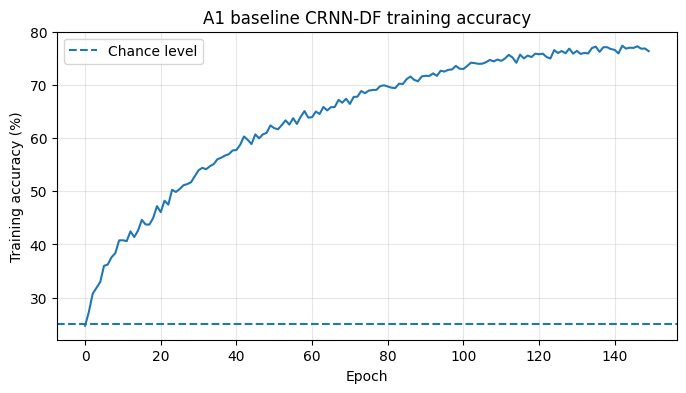

In [15]:
hist = demo_result["baseline_history"]

plt.figure(figsize=(8, 4))
plt.plot(hist["train_acc"])
plt.axhline(25, linestyle="--", label="Chance level")
plt.xlabel("Epoch")
plt.ylabel("Training accuracy (%)")
plt.title("A1 baseline CRNN-DF training accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step 3 — Full baseline LOSO

In [17]:
# Uncomment after the A1 baseline behaves sensibly.

baseline_results = run_full_loso(
    run_gan=False,
    resume=True
)

Loading completed fold A1: paper_replication_checkpoints/A1_result.pkl

Running baseline mean: 44.79%

TARGET SUBJECT A2
source=4608, calibration=288, test=288
  Applying 1-38 Hz preprocessing...

[R2] Sparse filter-bank CSP
  CSP band 01/10: 1-4 Hz
  CSP band 02/10: 4-8 Hz
  CSP band 03/10: 8-12 Hz
  CSP band 04/10: 12-16 Hz
  CSP band 05/10: 16-20 Hz
  CSP band 06/10: 20-24 Hz
  CSP band 07/10: 24-28 Hz
  CSP band 08/10: 28-32 Hz
  CSP band 09/10: 32-35 Hz
  CSP band 10/10: 35-38 Hz
Selected CSP features: 24 / 160

[R4] Baseline CRNN-DF
      ep   1/150 [CE-only] loss=1.3885 train=25.09%
      ep  20/150 [CE-only] loss=1.2189 train=41.23%
      initializing feature centers
      ep  40/150 [CE+center] loss=1.2437 train=51.58%
      ep  60/150 [CE+center] loss=1.0883 train=61.07%
      ep  80/150 [CE+center] loss=0.9768 train=67.17%
      ep 100/150 [CE+center] loss=0.8951 train=71.03%
      ep 120/150 [CE+center] loss=0.8340 train=74.74%
      ep 140/150 [CE+center] loss=0.8014 train

KeyboardInterrupt: 

## Step 4 — Test GAN augmentation on A1

In [ ]:
# WARNING: expensive.
# Run only after the baseline pipeline has been validated.

# gan_demo_result = run_fold(
#     "1",
#     run_gan=True
# )

# plot_gan_losses(
#     gan_demo_result["gan_history"],
#     subject_name="A1"
# )

## Step 5 — Full FBGAN LOSO

In [ ]:
# WARNING: very expensive on CPU/MPS.
# Completed subject checkpoints are automatically reused.

# full_results = run_full_loso(
#     run_gan=True,
#     resume=True
# )

## Final notes

- Do not compare an experimental run to the paper target until the baseline pipeline is stable.
- Check subject-level accuracy rather than only the mean.
- Check GAN loss curves, PSD similarity, covariance structure, and class separability before assuming generated trials are useful.
- A GAN loss value alone does not prove generated EEG quality.
- If augmentation reduces performance, inspect generated-signal quality before changing the classifier.